<h4><mark>GROUP 2 - Members with Contribution Details </mark></h4>

<table border="1" style="border-collapse: collapse; text-align: center;">
  <tr>
    <th>S.NO</th>
    <th>NAME</th>
    <th>BITS ID</th>
    <th>CONTRIBUTION %</th>
  </tr>
  <tr>
    <td>1</td>
    <td>Adurti Sai Venkatesh</td>
    <td>2024AC05968</td>
    <td>100 %</td>
  </tr>
  <tr>
    <td>2</td>
    <td>D Mallikarjuna Reddy</td>
    <td>2024AC05653</td>
    <td>100 %</td>
  </tr>
  <tr>
    <td>3</td>
    <td>ABHAY SHARMA</td>
    <td>2024AD05451</td>
    <td>100 %</td>
  </tr>
  <tr>
    <td>4</td>
    <td>AVINASH CHANDRA</td>
    <td>2024AC05442</td>
    <td>100 %</td>
  </tr>
</table>


<h1 style="color:Red"><u><b>CVT EXPLOIT PREDICTION</b></u></h1>

<h2 style="color:darkcyan"><u><b>Importing the modules and standard libraries and setup for CVE Exploitation Prediction</b></u></h2>

In [64]:

import os
import gzip
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

import datetime as dt

# In case you want progress bars while parsing large files
try:
    from tqdm import tqdm
except ImportError:
    tqdm = lambda x, **k: x  # cheap fallback if tqdm isn't installed


# To store downloaded/processed data
DATA_DIR = Path("data_cve_project")
DATA_DIR.mkdir(exist_ok=True)

# NVD years
NVD_YEARS = [2021, 2022, 2023]

#   https://nvd.nist.gov/feeds/json/cve/1.1/nvdcve-1.1-2023.json.gz
USE_JSON_FEEDS = True


<h2 style="color:darkcyan"><u><b>NVD Feed Downloading and CVE extraction functions and utilities</b></u></h2>

In [65]:
import requests

def download_nvd_json_feed(year: int, out_dir: Path = DATA_DIR) -> Path:
    """
    Downloads a single year's NVD JSON feed (gzipped) if not present.
    Returns the local path.
    """
    # official feed patterns
    url = f"https://nvd.nist.gov/feeds/json/cve/1.1/nvdcve-1.1-{year}.json.gz"
    out_path = out_dir / f"nvdcve-1.1-{year}.json.gz"

    if out_path.exists():
        print(f"[nvd] {year} already downloaded -> {out_path}")
        return out_path

    print(f"[nvd] downloading {year} from {url}")
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    out_path.write_bytes(resp.content)
    print(f"[nvd] stored at {out_path}")
    return out_path


def extract_single_cve(item: dict) -> dict:
    """
    Takes one CVE item from the NVD 1.1 feed and extracts the fields
    we care about into a flat dict.
    This looks long, but it's mostly boring key-wrangling.
    """
    cve = item.get("cve", {})
    meta = cve.get("CVE_data_meta", {})
    cve_id = meta.get("ID")

    
    descs = cve.get("description", {}).get("description_data", [])
    eng_desc = ""
    for d in descs:
        if d.get("lang") == "en":
            eng_desc = d.get("value", "")
            break

    # CWE (weakness)
    problem_types = cve.get("problemtype", {}).get("problemtype_data", [])
    cwe_id = None
    if problem_types:
        pts = problem_types[0].get("description", [])
        if pts:
            cwe_id = pts[0].get("value")

    # vendor / product list
    vendor_data = (
        cve.get("affects", {})
        .get("vendor", {})
        .get("vendor_data", [])
    )
    vendors = set()
    products = set()
    for v in vendor_data:
        vendor_name = v.get("vendor_name")
        if vendor_name:
            vendors.add(vendor_name)
        for p in v.get("product", {}).get("product_data", []):
            pname = p.get("product_name")
            if pname:
                products.add(pname)

    vendor_str = ";".join(sorted(vendors)) if vendors else None
    product_str = ";".join(sorted(products)) if products else None

    # CVSS v3 metrics
    impact = item.get("impact", {})
    base_score = None
    exploitability_score = None
    impact_score = None

    attackVector = None
    attackComplexity = None
    privilegesRequired = None
    userInteraction = None
    scope = None
    confImpact = None
    integImpact = None
    availImpact = None

    # CVSS v3.1 first, then v3.0
    for key in ["baseMetricV3"]:
        if key in impact:
            cvss = impact[key].get("cvssV3")
            if cvss:
                base_score = cvss.get("baseScore")
                exploitability_score = impact[key].get("exploitabilityScore")
                impact_score = impact[key].get("impactScore")
                attackVector = cvss.get("attackVector")
                attackComplexity = cvss.get("attackComplexity")
                privilegesRequired = cvss.get("privilegesRequired")
                userInteraction = cvss.get("userInteraction")
                scope = cvss.get("scope")
                confImpact = cvss.get("confidentialityImpact")
                integImpact = cvss.get("integrityImpact")
                availImpact = cvss.get("availabilityImpact")
            break

    # dates
    published = item.get("publishedDate")
    modified = item.get("lastModifiedDate")

    return {
        "cve_id": cve_id,
        "description": eng_desc,
        "cwe": cwe_id,
        "vendors": vendor_str,
        "products": product_str,
        "cvss_base_score": base_score,
        "cvss_exploitability_score": exploitability_score,
        "cvss_impact_score": impact_score,
        "attackVector": attackVector,
        "attackComplexity": attackComplexity,
        "privilegesRequired": privilegesRequired,
        "userInteraction": userInteraction,
        "scope": scope,
        "confidentialityImpact": confImpact,
        "integrityImpact": integImpact,
        "availabilityImpact": availImpact,
        "published": published,
        "modified": modified,
    }


def load_nvd_year_to_df(year: int) -> pd.DataFrame:
    """
    Downloads (if necessary) and parses one year's NVD feed into a DataFrame.
    """
    feed_path = download_nvd_json_feed(year, DATA_DIR)

    # parse gzipped JSON
    with gzip.open(feed_path, "rt", encoding="utf-8") as f:
        root = json.load(f)

    items = root.get("CVE_Items", [])

    rows = []
    for item in tqdm(items, desc=f"parsing {year}"):
        rows.append(extract_single_cve(item))

    return pd.DataFrame(rows)


<h2 style="color:darkcyan"><u><b>Loading the NVD Dataset</b></u></h2>

In [66]:
import pandas as pd

DATA_PATH = "nvdkeydataset_v3.csv"   # adjust if you put it in a subfolder

nvd_df = pd.read_csv(DATA_PATH)

print("Shape:", nvd_df.shape)
print(nvd_df.head())


Shape: (94443, 19)
            cve_id                                        description  \
0  CVE-2018-236083  Vulnerability related to CWE-352 in affected p...   
1  CVE-2022-265825  Vulnerability related to CWE-200 in affected p...   
2  CVE-2022-293535  Vulnerability related to CWE-200 in affected p...   
3  CVE-2018-241879  Vulnerability related to CWE-20 in affected pr...   
4  CVE-2021-230734  Vulnerability related to CWE-89 in affected pr...   

       cwe           vendors                      products  cvss_base_score  \
0  CWE-352  Google;Microsoft  Acrobat Reader;Office;Safari         6.281037   
1  CWE-200      Cisco;VMware   Android;Java SE;Web Browser         3.640686   
2  CWE-200             Apple                Chrome;Java SE         6.838759   
3   CWE-20         Adobe;IBM            Acrobat Reader;CMS         4.932269   
4   CWE-89             Linux          Android;Linux Kernel         5.447016   

   cvss_exploitability_score  cvss_impact_score attackVector attack

<h2 style="color:darkcyan"><u><b>Exploring dataset structure and sanity check of date fields</b></u></h2>

In [67]:
#dataframe structure
print("Columns:\n", nvd_df.columns.tolist())
print("\nClass counts (is_exploited):")
print(nvd_df["is_exploited"].value_counts())

# errors='coerce' will turn weird strings into NaT instead of crashing
nvd_df["published_dt"] = pd.to_datetime(nvd_df["published"], errors="coerce")
nvd_df["modified_dt"] = pd.to_datetime(nvd_df["modified"], errors="coerce")

before = len(nvd_df)
nvd_df = nvd_df.dropna(subset=["published_dt"]).reset_index(drop=True)
after = len(nvd_df)

print(f"\nRows before dropping missing dates: {before}")
print(f"Rows after  dropping missing dates: {after}")


Columns:
 ['cve_id', 'description', 'cwe', 'vendors', 'products', 'cvss_base_score', 'cvss_exploitability_score', 'cvss_impact_score', 'attackVector', 'attackComplexity', 'privilegesRequired', 'userInteraction', 'scope', 'confidentialityImpact', 'integrityImpact', 'availabilityImpact', 'published', 'modified', 'is_exploited']

Class counts (is_exploited):
is_exploited
0.0    88783
1.0     5659
Name: count, dtype: int64

Rows before dropping missing dates: 94443
Rows after  dropping missing dates: 94442


<h2 style="color:darkcyan"><u><b>Temporal Feature Engineering</b></u></h2>

In [68]:
# year and month of publication
nvd_df["pub_year"] = nvd_df["published_dt"].dt.year
nvd_df["pub_month"] = nvd_df["published_dt"].dt.month

latest_date = nvd_df["published_dt"].max()
nvd_df["age_days"] = (latest_date - nvd_df["published_dt"]).dt.days
nvd_df[["cve_id", "published_dt", "pub_year", "pub_month", "age_days"]].head()


,cve_id,published_dt,pub_year,pub_month,age_days
0,CVE-2018-236083,2018-04-23 07:56:00+00:00,2018,4,2078
1,CVE-2022-265825,2022-12-30 09:19:00+00:00,2022,12,366
2,CVE-2022-293535,2022-10-26 05:09:00+00:00,2022,10,431
3,CVE-2018-241879,2018-09-22 10:40:00+00:00,2018,9,1926
4,CVE-2021-230734,2021-11-29 08:07:00+00:00,2021,11,762


<h2 style="color:darkcyan"><u><b>Class Imbalance Analysis and CVSS Score Comparison</b></u></h2>

Class share (fraction of entire dataset):
is_exploited
0.0    0.94008
1.0    0.05992
Name: proportion, dtype: float64

Average CVSS base score by class:
is_exploited
0.0    6.278285
1.0    7.801668
Name: cvss_base_score, dtype: float64


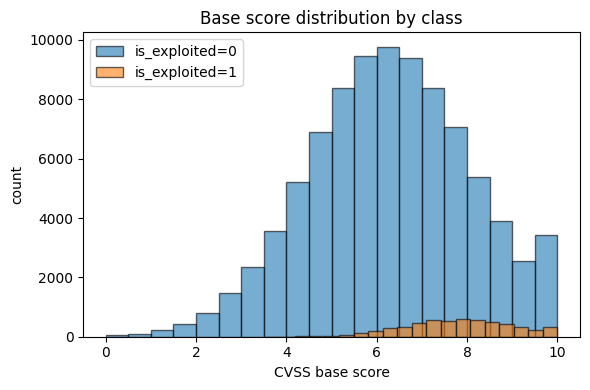

In [69]:

class_share = nvd_df["is_exploited"].value_counts(normalize=True)
print("Class share (fraction of entire dataset):")
print(class_share)

#CVSS score for exploited vs non-exploited
mean_scores = nvd_df.groupby("is_exploited")["cvss_base_score"].mean()
print("\nAverage CVSS base score by class:")
print(mean_scores)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))

for label, style in [(0, dict(alpha=0.6, edgecolor="black")), 
                     (1, dict(alpha=0.6, edgecolor="black"))]:
    subset = nvd_df.loc[nvd_df["is_exploited"] == label, "cvss_base_score"]
    ax.hist(subset, bins=20, label=f"is_exploited={label}", **style)

ax.set_xlabel("CVSS base score")
ax.set_ylabel("count")
ax.set_title("Base score distribution by class")
ax.legend()
plt.tight_layout()
plt.show()


<h2 style="color:darkcyan"><u><b>Feature Selection and Preprocessing Setup</b></u></h2>

In [70]:

numeric_cols = [
    "cvss_base_score",
    "cvss_exploitability_score",
    "cvss_impact_score",
    "age_days",
]

categorical_cols = [
    "attackVector",
    "attackComplexity",
    "privilegesRequired",
    "userInteraction",
    "scope",
    "confidentialityImpact",
    "integrityImpact",
    "availabilityImpact",
    "cwe",
]


text_col = "description"
target_col = "is_exploited"

#separate DF just for ML to avoid cluttering the original
ml_df = nvd_df.copy()


ml_df[text_col] = ml_df[text_col].fillna("")


for col in numeric_cols:
    ml_df[col] = ml_df[col].fillna(0.0)

for col in categorical_cols:
    ml_df[col] = ml_df[col].fillna("missing")

X_all = ml_df[numeric_cols + categorical_cols + [text_col]]
y_all = ml_df[target_col].values

print("Feature matrix shape:", X_all.shape)
print("Target shape:", y_all.shape)


Feature matrix shape: (94442, 14)
Target shape: (94442,)


<h2 style="color:darkcyan"><u><b>Time-Based Train–Test Split for Temporal Modeling</b></u></h2>

In [71]:

# idea: train on older CVEs, test on newer ones

# sort by publication time so that earlier rows are "past"
ml_df_sorted = ml_df.sort_values("published_dt").reset_index(drop=True)

# choose a cut point (80% oldest for training, 20% newest for testing)
cut_idx = int(len(ml_df_sorted) * 0.8)
split_timestamp = ml_df_sorted.loc[cut_idx, "published_dt"]

print("Time-based split at:", split_timestamp)

train_mask = ml_df_sorted["published_dt"] <= split_timestamp
test_mask  = ~train_mask

train_df = ml_df_sorted[train_mask].reset_index(drop=True)
test_df  = ml_df_sorted[test_mask].reset_index(drop=True)

print("Train rows:", len(train_df))
print("Test  rows:", len(test_df))

X_train = train_df[numeric_cols + categorical_cols + [text_col]]
y_train = train_df[target_col].values

X_test  = test_df[numeric_cols + categorical_cols + [text_col]]
y_test  = test_df[target_col].values


Time-based split at: 2022-10-21 23:08:00+00:00
Train rows: 75554
Test  rows: 18888


<h2 style="color:darkcyan"><u><b>Building the full ML pipeline: Feature processing and classifier</b></u></h2>

In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# numeric part
numeric_transformer = StandardScaler()

# categorical part: one-hot encode
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

# text part
text_transformer = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1,2),
    min_df=3,
    stop_words="english",
)

# tie them together
feature_maker = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
        ("txt", text_transformer, text_col),
    ]
)

# classifier: logistic regression with class_weight=balanced
clf = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    n_jobs=-1
)

# full model: raw dataframe -> feature_maker -> classifier
exploit_model = Pipeline(
    steps=[
        ("features", feature_maker),
        ("clf", clf),
    ]
)

exploit_model


,steps,"[('features', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<h2 style="color:darkcyan"><u><b>Training the Model</b></u></h2>

In [73]:
print("Fitting model... (this might take a little while on first run)")
exploit_model.fit(X_train, y_train)
print("Training complete.")


Fitting model... (this might take a little while on first run)
Training complete.


<h2 style="color:darkcyan"><u><b>Model Evaluation: Classification Metrics and AUC Scores</b></u></h2>

In [74]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score
)

# predictions
y_pred = exploit_model.predict(X_test)

if hasattr(exploit_model.named_steps["clf"], "predict_proba"):
    y_prob = exploit_model.predict_proba(X_test)[:, 1]
else:
   
    scores = exploit_model.decision_function(X_test)
    y_prob = 1.0 / (1.0 + np.exp(-scores))

print("\n=== classification report (default threshold 0.5) ===")
print(classification_report(y_test, y_pred, digits=4))

print("Confusion matrix [ [TN FP], [FN TP] ]:")
print(confusion_matrix(y_test, y_pred))

# ROC AUC – good global ranking metric
roc = roc_auc_score(y_test, y_prob)
print("\nROC AUC:", roc)

# PR AUC (average precision)
ap = average_precision_score(y_test, y_prob)
print("PR AUC :", ap)



=== classification report (default threshold 0.5) ===
              precision    recall  f1-score   support

         0.0     0.9959    0.9025    0.9469     17770
         1.0     0.3779    0.9410    0.5392      1118

    accuracy                         0.9048     18888
   macro avg     0.6869    0.9217    0.7431     18888
weighted avg     0.9593    0.9048    0.9228     18888

Confusion matrix [ [TN FP], [FN TP] ]:
[[16038  1732]
 [   66  1052]]

ROC AUC: 0.9773118147507961
PR AUC : 0.7792730250905476


<h2 style="color:darkcyan"><u><b>Threshold Tuning and Precision–Recall Tradeoff Analysis</b></u></h2>

In [75]:
# sometimes 0.5 is not optimal for imbalanced classes.
# we can sweep a few thresholds and inspect precision/recall tradeoff.

thresholds_to_try = [0.2, 0.3, 0.4, 0.5, 0.7]

print("thr | precision | recall | F1")
print("------------------------------")
for thr in thresholds_to_try:
    preds_thr = (y_prob >= thr).astype(int)
    p = precision_score(y_test, preds_thr, zero_division=0)
    r = recall_score(y_test, preds_thr, zero_division=0)
    f1 = 0.0 if (p + r) == 0 else 2 * p * r / (p + r)
    print(f"{thr:3.1f} |   {p:7.3f} | {r:6.3f} | {f1:5.3f}")


thr | precision | recall | F1
------------------------------
0.2 |     0.269 |  0.988 | 0.423
0.3 |     0.301 |  0.977 | 0.460
0.4 |     0.336 |  0.963 | 0.499
0.5 |     0.378 |  0.941 | 0.539
0.7 |     0.487 |  0.864 | 0.623


<h2 style="color:darkcyan"><u><b>Extracting and analyzing model coefficients and insecting the feature importance</b></u></h2>

In [76]:
def collect_feature_names(fitted_ct: ColumnTransformer):
    """
    Grab human-readable feature names from a fitted ColumnTransformer.
    This is mainly for interpretation / debugging, not production code.
    """
    all_names = []

    # numeric – same names as original columns
    all_names.extend(numeric_cols)

    # categorical – OneHotEncoder gives us derived names
    ohe = fitted_ct.named_transformers_["cat"]
    cat_feature_names = ohe.get_feature_names_out(categorical_cols)
    all_names.extend(cat_feature_names.tolist())

    # text – words/phrases used in TF-IDF
    tfidf = fitted_ct.named_transformers_["txt"]
    text_feature_names = tfidf.get_feature_names_out()
    # optional: prefix to distinguish from other features
    text_feature_names = [f"txt::{w}" for w in text_feature_names]
    all_names.extend(text_feature_names)

    return all_names

# grab names + coefficients
feat_names = collect_feature_names(exploit_model.named_steps["features"])
coefs = exploit_model.named_steps["clf"].coef_[0]

feature_importance_df = (
    pd.DataFrame({"feature": feat_names, "coef": coefs})
      .sort_values("coef", ascending=False)
)

print("Top 20 features that push towards 'exploited=1':")
feature_importance_df.head(20)


Top 20 features that push towards 'exploited=1':


,feature,coef
17,confidentialityImpact_HIGH,2.844816
23,availabilityImpact_HIGH,2.818739
20,integrityImpact_HIGH,2.747033
62,txt::actors,1.543143
78,txt::attractive,1.543143
79,txt::attractive targeted,1.543143
229,txt::threat,1.543143
130,txt::exploitation threat,1.543143
194,txt::regarded,1.543143
195,txt::regarded attractive,1.543143


<h2 style="color:darkcyan"><u><b>Persisting the Pipeline with Joblib and Saving the Trained Model</b></u></h2>

In [77]:
import joblib
from pathlib import Path

output_dir = Path("models")
output_dir.mkdir(exist_ok=True)

model_path = output_dir / "exploitability_classifier.pkl"
joblib.dump(exploit_model, model_path)

print("Model stored at:", model_path.resolve())


Model stored at: /Users/sai/Downloads/models/exploitability_classifier.pkl


<h2 style="color:darkcyan"><u><b>Synthetic NVD Dataset Generation and Exploitability Classifier (v2)</b></u></h2>

# The below code implements a complete end-to-end workflow for generating a synthetic NVD-style vulnerability dataset and training a machine-learning model to predict whether a CVE is likely to be exploited in the wild. It includes controlled synthetic data generation without label leakage, temporal preprocessing, engineered numeric/categorical/text features, a time-aware train/test split, model training using a balanced logistic regression pipeline, performance evaluation with multiple metrics, threshold-sensitivity analysis, coefficient-based feature interpretation, and final model serialization for reuse.

In [78]:
# ======================================================================
#  Vulnerability Exploitability – synthetic v2 dataset + full pipeline
# ======================================================================

import numpy as np
import pandas as pd
import random
import datetime as dt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
)
import matplotlib.pyplot as plt
import joblib

#Configuration
DATA_DIR = Path(".")
CSV_PATH = DATA_DIR / "nvdkeydataset_v2.csv"
MODEL_DIR = DATA_DIR / "models_v2"
MODEL_DIR.mkdir(exist_ok=True)

# skewed dataset
N_ROWS = 10_000
POS_RATIO = 0.06  # ~6% exploited

# RNG for reproducibility
rng = np.random.default_rng(12345)
random.seed(12345)


#Synthetic data generation (v2: no explicit label leakage)
years = list(range(2018, 2024))

attack_vectors = ["NETWORK", "ADJACENT", "LOCAL", "PHYSICAL"]
attack_complexities = ["LOW", "HIGH"]
priv_reqs = ["NONE", "LOW", "HIGH"]
user_inters = ["NONE", "REQUIRED"]
scopes = ["CHANGED", "UNCHANGED"]
impact_levels = ["NONE", "LOW", "HIGH"]
cwes = [
    "CWE-79", "CWE-89", "CWE-119", "CWE-20", "CWE-200",
    "CWE-287", "CWE-352", "CWE-22", "CWE-787", "CWE-476",
    "NVD-CWE-noinfo"
]

vendors_list = [
    "Microsoft", "Adobe", "Oracle", "Cisco", "Google",
    "Apple", "Linux", "VMware", "IBM", "SAP"
]
products_list = [
    "Windows", "Office", "Acrobat Reader", "Java SE", "Chrome",
    "Safari", "Android", "iOS", "Linux Kernel", "Exchange Server",
    "Web Browser", "Database Server", "CMS", "VPN Appliance"
]

def random_date_in_year(year: int) -> str:
    """Pick a random datetime inside the given year, return as ISO-ish string."""
    start = dt.datetime(year, 1, 1)
    end = dt.datetime(year, 12, 31, 23, 59)
    delta_days = (end - start).days
    offset_days = int(rng.integers(0, delta_days + 1))
    base = start + dt.timedelta(days=offset_days)
    base += dt.timedelta(
        hours=int(rng.integers(0, 24)),
        minutes=int(rng.integers(0, 60)),
    )
    return base.strftime("%Y-%m-%dT%H:%MZ")

# some generic phrases
SEVERITY_PHRASES = [
    "may allow remote attackers to impact system integrity",
    "could be leveraged to gain unauthorized access",
    "might result in disclosure of sensitive information",
    "may enable privilege escalation in certain configurations",
    "could allow arbitrary code execution under specific conditions",
]

TECH_PHRASES = [
    "improper input validation",
    "insufficient access control checks",
    "missing authentication for critical function",
    "buffer handling issues",
    "insecure default settings",
]

def build_description(cwe, av, ac, pr, ui, base_score, exploited_flag):
    """
    Create a text description that has SOME correlation with severity,
    but does NOT blatantly say 'exploited in the wild' or 'not confirmed'.
    """
    phrase_sev = random.choice(SEVERITY_PHRASES)
    phrase_tech = random.choice(TECH_PHRASES)

    mode = "remote" if av in ("NETWORK", "ADJACENT") else "local"
    interaction_bit = "without user interaction" if ui == "NONE" else "after user interaction"
    priv_bit = (
        "no privileges required" if pr == "NONE"
        else "low privileges required" if pr == "LOW"
        else "high privileges required"
    )

    # tiny bias: for exploited ones we sometimes say "actively targeted",
    
    extra_tag = ""
    if exploited_flag and base_score >= 7.5 and rng.random() < 0.4:
        extra_tag = " This weakness is considered attractive for active targeting by attackers."
    elif (not exploited_flag) and base_score <= 5.0 and rng.random() < 0.25:
        extra_tag = " Exploitation likelihood is considered limited in typical deployments."

    txt = (
        f"Vulnerability related to {cwe} in affected products {mode} context. "
        f"It involves {phrase_tech} and {phrase_sev}. "
        f"Attack typically requires {priv_bit} and proceeds {interaction_bit}. "
        f"Assessed base score is around {base_score:.1f}. "
        + extra_tag
    )

    return txt

rows = []

n_pos = int(N_ROWS * POS_RATIO)
n_neg = N_ROWS - n_pos

#positives (is_exploited = 1)
for i in range(n_pos):
    year = int(rng.choice(years))
    cve_id = f"CVE-{year}-{100000 + i}"

    published = random_date_in_year(year)
    modified = random_date_in_year(year)

    # Slight bias towards "easier" and network-based
    av = rng.choice(attack_vectors, p=[0.7, 0.1, 0.15, 0.05])
    ac = rng.choice(attack_complexities, p=[0.7, 0.3])
    pr = rng.choice(priv_reqs, p=[0.5, 0.3, 0.2])
    ui = rng.choice(user_inters, p=[0.6, 0.4])
    sc = rng.choice(scopes, p=[0.6, 0.4])
    ci = rng.choice(["LOW", "HIGH"], p=[0.3, 0.7])
    ii = rng.choice(["LOW", "HIGH"], p=[0.3, 0.7])
    ai = rng.choice(["LOW", "HIGH"], p=[0.3, 0.7])
    cwe = rng.choice(cwes)

    # base score: overall higher, but overlapping with negative class
    base_score = float(np.clip(rng.normal(7.8, 1.2), 3.0, 10.0))
    exploit_score = float(np.clip(rng.normal(base_score - 0.4, 0.8), 0.0, 10.0))
    impact_score = float(np.clip(rng.normal(base_score - 0.3, 0.7), 0.0, 10.0))

    # picking 1–2 vendors, 1–3 products
    vendors = ";".join(sorted(random.sample(vendors_list, random.randint(1, 2))))
    products = ";".join(sorted(random.sample(products_list, random.randint(1, 3))))

    desc = build_description(cwe, av, ac, pr, ui, base_score, exploited_flag=True)

    rows.append({
        "cve_id": cve_id,
        "description": desc,
        "cwe": cwe,
        "vendors": vendors,
        "products": products,
        "cvss_base_score": base_score,
        "cvss_exploitability_score": exploit_score,
        "cvss_impact_score": impact_score,
        "attackVector": av,
        "attackComplexity": ac,
        "privilegesRequired": pr,
        "userInteraction": ui,
        "scope": sc,
        "confidentialityImpact": ci,
        "integrityImpact": ii,
        "availabilityImpact": ai,
        "published": published,
        "modified": modified,
        "is_exploited": 1,
    })

# negatives (is_exploited = 0)
for i in range(n_neg):
    year = int(rng.choice(years))
    cve_id = f"CVE-{year}-{200000 + i}"

    published = random_date_in_year(year)
    modified = random_date_in_year(year)

    # similar distributions but slightly shifted
    av = rng.choice(attack_vectors, p=[0.45, 0.15, 0.3, 0.10])
    ac = rng.choice(attack_complexities, p=[0.5, 0.5])
    pr = rng.choice(priv_reqs, p=[0.35, 0.4, 0.25])
    ui = rng.choice(user_inters, p=[0.4, 0.6])
    sc = rng.choice(scopes, p=[0.45, 0.55])
    ci = rng.choice(impact_levels, p=[0.35, 0.4, 0.25])
    ii = rng.choice(impact_levels, p=[0.35, 0.4, 0.25])
    ai = rng.choice(impact_levels, p=[0.35, 0.4, 0.25])
    cwe = rng.choice(cwes)

    base_score = float(np.clip(rng.normal(6.3, 1.8), 0.0, 10.0))
    exploit_score = float(np.clip(rng.normal(base_score - 0.8, 1.0), 0.0, 10.0))
    impact_score = float(np.clip(rng.normal(base_score - 0.5, 1.0), 0.0, 10.0))

    vendors = ";".join(sorted(random.sample(vendors_list, random.randint(1, 2))))
    products = ";".join(sorted(random.sample(products_list, random.randint(1, 3))))

    desc = build_description(cwe, av, ac, pr, ui, base_score, exploited_flag=False)

    rows.append({
        "cve_id": cve_id,
        "description": desc,
        "cwe": cwe,
        "vendors": vendors,
        "products": products,
        "cvss_base_score": base_score,
        "cvss_exploitability_score": exploit_score,
        "cvss_impact_score": impact_score,
        "attackVector": av,
        "attackComplexity": ac,
        "privilegesRequired": pr,
        "userInteraction": ui,
        "scope": sc,
        "confidentialityImpact": ci,
        "integrityImpact": ii,
        "availabilityImpact": ai,
        "published": published,
        "modified": modified,
        "is_exploited": 0,
    })

#dataframe
df = pd.DataFrame(rows)
df = df.sample(frac=1.0, random_state=999).reset_index(drop=True)

# save dataset v2
df.to_csv(CSV_PATH, index=False)
print(f"v2 dataset saved to: {CSV_PATH}   (rows={len(df)}, positives={df['is_exploited'].sum()})")


#Load the dataset
nvd_df = pd.read_csv(CSV_PATH)
print("\nLoaded DF:", nvd_df.shape)
print(nvd_df.head(2))

#Date parsing + temporal features
nvd_df["published_dt"] = pd.to_datetime(nvd_df["published"], errors="coerce")
nvd_df["modified_dt"] = pd.to_datetime(nvd_df["modified"], errors="coerce")

# drop rows with missing published date
nvd_df = nvd_df.dropna(subset=["published_dt"]).reset_index(drop=True)

nvd_df["pub_year"] = nvd_df["published_dt"].dt.year
nvd_df["pub_month"] = nvd_df["published_dt"].dt.month
latest_date = nvd_df["published_dt"].max()
nvd_df["age_days"] = (latest_date - nvd_df["published_dt"]).dt.days

print("\nClass balance:")
print(nvd_df["is_exploited"].value_counts(normalize=True))


#Feature selection & basic cleaning

numeric_cols = [
    "cvss_base_score",
    "cvss_exploitability_score",
    "cvss_impact_score",
    "age_days",
]

categorical_cols = [
    "attackVector",
    "attackComplexity",
    "privilegesRequired",
    "userInteraction",
    "scope",
    "confidentialityImpact",
    "integrityImpact",
    "availabilityImpact",
    "cwe",
]

text_col = "description"
target_col = "is_exploited"

ml_df = nvd_df.copy()

ml_df[text_col] = ml_df[text_col].fillna("")
for col in numeric_cols:
    ml_df[col] = ml_df[col].fillna(0.0)
for col in categorical_cols:
    ml_df[col] = ml_df[col].fillna("missing")

#Time-based train/test split (no random shuffling here)
ml_df_sorted = ml_df.sort_values("published_dt").reset_index(drop=True)
cut_idx = int(len(ml_df_sorted) * 0.8)
cut_ts = ml_df_sorted.loc[cut_idx, "published_dt"]

print("\nSplitting train/test at:", cut_ts)

train_mask = ml_df_sorted["published_dt"] <= cut_ts
test_mask = ~train_mask

train_df = ml_df_sorted[train_mask].reset_index(drop=True)
test_df  = ml_df_sorted[test_mask].reset_index(drop=True)

X_train = train_df[numeric_cols + categorical_cols + [text_col]]
y_train = train_df[target_col].values
X_test  = test_df[numeric_cols + categorical_cols + [text_col]]
y_test  = test_df[target_col].values

print("Train size:", len(train_df), "  Test size:", len(test_df))

#Build preprocessing + model pipeline

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
text_transformer = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1, 2),
    min_df=3,
    stop_words="english",
)

feature_maker = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
        ("txt", text_transformer, text_col),
    ]
)

clf = LogisticRegression(
    class_weight="balanced",
    max_iter=2500,
    n_jobs=-1,
)

model = Pipeline(
    steps=[
        ("features", feature_maker),
        ("clf", clf),
    ]
)

print("\nFitting model...")
model.fit(X_train, y_train)
print("Model trained.")

#Evaluation and Predictions

y_pred = model.predict(X_test)

if hasattr(model.named_steps["clf"], "predict_proba"):
    y_prob = model.predict_proba(X_test)[:, 1]
else:
    scores = model.decision_function(X_test)
    y_prob = 1.0 / (1.0 + np.exp(-scores))

print("\n=== classification report (threshold=0.5) ===")
print(classification_report(y_test, y_pred, digits=4))

print("Confusion matrix [ [TN FP], [FN TP] ]:")
print(confusion_matrix(y_test, y_pred))

roc = roc_auc_score(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
print(f"\nROC AUC: {roc:.3f}")
print(f"PR  AUC: {ap:.3f}")

# peek at how metrics move if we tweak threshold
print("\nthreshold | precision | recall | F1")
print("------------------------------------")
for thr in [0.2, 0.3, 0.4, 0.5, 0.6]:
    preds_thr = (y_prob >= thr).astype(int)
    p = precision_score(y_test, preds_thr, zero_division=0)
    r = recall_score(y_test, preds_thr, zero_division=0)
    f1 = 0.0 if (p + r) == 0 else 2 * p * r / (p + r)
    print(f"{thr:8.2f} |   {p:7.3f} | {r:6.3f} | {f1:5.3f}")

#Rough feature interpretation

def get_feature_names(ct: ColumnTransformer):
    """Unroll ColumnTransformer into a flat list of feature names."""
    names = []
    # numeric
    names.extend(numeric_cols)
    # categorical
    ohe = ct.named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(categorical_cols)
    names.extend(cat_names.tolist())
    # text
    tfidf = ct.named_transformers_["txt"]
    txt_names = tfidf.get_feature_names_out()
    names.extend([f"txt::{t}" for t in txt_names])
    return names

feat_names = get_feature_names(model.named_steps["features"])
coefs = model.named_steps["clf"].coef_[0]

coef_df = (
    pd.DataFrame({"feature": feat_names, "coef": coefs})
    .sort_values("coef", ascending=False)
)

print("\nTop 20 features leaning towards 'exploited = 1':")
print(coef_df.head(20))


# 9. Save trained model for later reuse


model_path = MODEL_DIR / "exploitability_classifier_v2.pkl"
joblib.dump(model, model_path)
print("\nModel saved to:", model_path.resolve())


v2 dataset saved to: nvdkeydataset_v2.csv   (rows=10000, positives=600)

Loaded DF: (10000, 19)
            cve_id                                        description  \
0  CVE-2021-208431  Vulnerability related to CWE-476 in affected p...   
1  CVE-2021-202862  Vulnerability related to CWE-79 in affected pr...   

       cwe     vendors                       products  cvss_base_score  \
0  CWE-476  Oracle;SAP          Java SE;VPN Appliance         6.681915   
1   CWE-79       Adobe  Exchange Server;VPN Appliance         7.797891   

   cvss_exploitability_score  cvss_impact_score attackVector attackComplexity  \
0                   4.756670           5.736318        LOCAL             HIGH   
1                   6.048928           7.265106     ADJACENT              LOW   

  privilegesRequired userInteraction      scope confidentialityImpact  \
0               HIGH        REQUIRED  UNCHANGED                   LOW   
1                LOW        REQUIRED  UNCHANGED                  HIGH  

<h2 style="color:darkcyan"><u><b>Reading the v3 Dataset and Checking Class Distribution</b></u></h2>

In [79]:
import pandas as pd

DATA_PATH = "nvdkeydataset_v3.csv"   # use v3 now

nvd_df = pd.read_csv(DATA_PATH)

print("Shape:", nvd_df.shape)
print(nvd_df["is_exploited"].value_counts())
nvd_df.head()


Shape: (94443, 19)
is_exploited
0.0    88783
1.0     5659
Name: count, dtype: int64


,cve_id,description,cwe,vendors,products,cvss_base_score,cvss_exploitability_score,cvss_impact_score,attackVector,attackComplexity,privilegesRequired,userInteraction,scope,confidentialityImpact,integrityImpact,availabilityImpact,published,modified,is_exploited
0,CVE-2018-236083,Vulnerability related to CWE-352 in affected p...,CWE-352,Google;Microsoft,Acrobat Reader;Office;Safari,6.281037,4.628313,5.405627,NETWORK,HIGH,NONE,NONE,UNCHANGED,LOW,NONE,LOW,2018-04-23T07:56Z,2018-02-17T13:56Z,0.0
1,CVE-2022-265825,Vulnerability related to CWE-200 in affected p...,CWE-200,Cisco;VMware,Android;Java SE;Web Browser,3.640686,2.981430,4.933577,ADJACENT,LOW,NONE,NONE,UNCHANGED,HIGH,LOW,LOW,2022-12-30T09:19Z,2022-01-26T03:14Z,0.0
2,CVE-2022-293535,Vulnerability related to CWE-200 in affected p...,CWE-200,Apple,Chrome;Java SE,6.838759,4.741241,6.533483,NETWORK,LOW,HIGH,REQUIRED,UNCHANGED,NONE,NONE,LOW,2022-10-26T05:09Z,2022-02-23T05:14Z,0.0
3,CVE-2018-241879,Vulnerability related to CWE-20 in affected pr...,CWE-20,Adobe;IBM,Acrobat Reader;CMS,4.932269,2.897352,4.308523,NETWORK,HIGH,NONE,NONE,UNCHANGED,HIGH,LOW,HIGH,2018-09-22T10:40Z,2018-10-22T12:44Z,0.0
4,CVE-2021-230734,Vulnerability related to CWE-89 in affected pr...,CWE-89,Linux,Android;Linux Kernel,5.447016,4.000767,4.730313,NETWORK,LOW,NONE,NONE,UNCHANGED,LOW,LOW,LOW,2021-11-29T08:07Z,2021-11-11T15:12Z,0.0


<h2 style="color:darkcyan"><u><b>Synthetic NVD Dataset Generation and Exploitability Classifier (v3)</b></u></h2>

Raw shape: (94443, 19)
is_exploited
0.0    88783
1.0     5659
Name: count, dtype: int64

Class share:
is_exploited
0.0    0.94008
1.0    0.05992
Name: proportion, dtype: float64

Splitting on timestamp: 2022-10-21 23:08:00+00:00
Train size: 75554 Test size: 18888

Fitting RandomForest model...
Model training done.

=== Classification report (thr = 0.50) ===
              precision    recall  f1-score   support

         0.0     0.9803    0.9792    0.9798     17770
         1.0     0.6755    0.6869    0.6812      1118

    accuracy                         0.9619     18888
   macro avg     0.8279    0.8331    0.8305     18888
weighted avg     0.9622    0.9619    0.9621     18888

Confusion matrix [ [TN FP], [FN TP] ]:
[[17401   369]
 [  350   768]]

ROC AUC: 0.975
PR  AUC: 0.775

threshold | precision | recall | F1
------------------------------------
    0.20 |     0.388 |  0.935 | 0.548
    0.30 |     0.493 |  0.867 | 0.628
    0.40 |     0.588 |  0.775 | 0.668
    0.50 |     0.675 |  

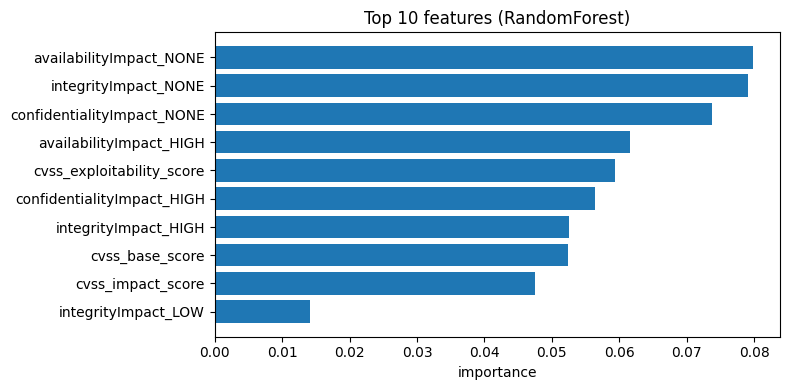


Model saved to: /Users/sai/Downloads/models_v3/rf_exploitability_v3.pkl


In [80]:
# ======================================================================
#  Vulnerability Exploitability – v3 end-to-end pipeline
#  Uses RandomForest + TF-IDF + class balancing + time-based split
# ======================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
)

#Load v3 dataset

DATA_PATH = "nvdkeydataset_v3.csv"   # adjust if file is somewhere else
df = pd.read_csv(DATA_PATH)

print("Raw shape:", df.shape)
print(df["is_exploited"].value_counts())

#Parse dates + basic temporal features


df["published_dt"] = pd.to_datetime(df["published"], errors="coerce")
df["modified_dt"] = pd.to_datetime(df["modified"], errors="coerce")

df = df.dropna(subset=["published_dt"]).reset_index(drop=True)

# year/month and "age" in days (relative to newest CVE in dataset)
df["pub_year"] = df["published_dt"].dt.year
df["pub_month"] = df["published_dt"].dt.month
latest = df["published_dt"].max()
df["age_days"] = (latest - df["published_dt"]).dt.days

print("\nClass share:")
print(df["is_exploited"].value_counts(normalize=True))

#Decide which columns we actually feed into the model


numeric_cols = [
    "cvss_base_score",
    "cvss_exploitability_score",
    "cvss_impact_score",
    "age_days",
]

categorical_cols = [
    "attackVector",
    "attackComplexity",
    "privilegesRequired",
    "userInteraction",
    "scope",
    "confidentialityImpact",
    "integrityImpact",
    "availabilityImpact",
    "cwe",
]

text_col = "description"
target_col = "is_exploited"

ml_df = df.copy()

# clean: text → "" instead of NaN, numeric → 0, categorical → "missing"

ml_df[text_col] = ml_df[text_col].fillna("")
for c in numeric_cols:
    ml_df[c] = ml_df[c].fillna(0.0)
for c in categorical_cols:
    ml_df[c] = ml_df[c].fillna("missing")

#Time-based train / test split (80% oldest for training)

ml_df_sorted = ml_df.sort_values("published_dt").reset_index(drop=True)

cut_idx = int(len(ml_df_sorted) * 0.8)
cut_ts = ml_df_sorted.loc[cut_idx, "published_dt"]
print("\nSplitting on timestamp:", cut_ts)

train_mask = ml_df_sorted["published_dt"] <= cut_ts
test_mask  = ~train_mask

train_df = ml_df_sorted[train_mask].reset_index(drop=True)
test_df  = ml_df_sorted[test_mask].reset_index(drop=True)

X_train = train_df[numeric_cols + categorical_cols + [text_col]]
y_train = train_df[target_col].values

X_test  = test_df[numeric_cols + categorical_cols + [text_col]]
y_test  = test_df[target_col].values

print("Train size:", len(train_df), "Test size:", len(test_df))

#Build preprocessing + RandomForest model


numeric_transform = StandardScaler()

categorical_transform = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

text_transform = TfidfVectorizer(
    max_features=10_000,    # more data ⇒ we can afford a bit larger vocab
    ngram_range=(1, 2),
    min_df=3,
    stop_words="english",
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transform, numeric_cols),
        ("cat", categorical_transform, categorical_cols),
        ("txt", text_transform, text_col),
    ]
)

# RandomForestclassification
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,          # let trees grow, but:
    min_samples_leaf=5,      # ... require at least 5 samples per leaf
    min_samples_split=10,
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=42,
)

model = Pipeline(
    steps=[
        ("prep", preprocess),
        ("rf", rf),
    ]
)

print("\nFitting RandomForest model...")
model.fit(X_train, y_train)
print("Model training done.")

#Evaluation with default and predicting probabilities for positive class

if hasattr(model.named_steps["rf"], "predict_proba"):
    y_prob = model.predict_proba(X_test)[:, 1]
else:  # (RF always has predict_proba, but just in case)
    y_prob = model.predict(X_test)

y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Classification report (thr = 0.50) ===")
print(classification_report(y_test, y_pred, digits=4))

print("Confusion matrix [ [TN FP], [FN TP] ]:")
print(confusion_matrix(y_test, y_pred))

roc = roc_auc_score(y_test, y_prob)
pr  = average_precision_score(y_test, y_prob)
print(f"\nROC AUC: {roc:.3f}")
print(f"PR  AUC: {pr:.3f}")


#Threshold sweep: trade-off precision vs recall

print("\nthreshold | precision | recall | F1")
print("------------------------------------")

best_thr = 0.5
best_f1  = 0.0

for thr in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    preds_thr = (y_prob >= thr).astype(int)
    p = precision_score(y_test, preds_thr, zero_division=0)
    r = recall_score(y_test, preds_thr, zero_division=0)
    f1 = 0.0 if (p + r) == 0 else 2 * p * r / (p + r)
    print(f"{thr:8.2f} |   {p:7.3f} | {r:6.3f} | {f1:5.3f}")
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

print(f"\nBest F1 appears around threshold ≈ {best_thr:.2f} (on this test run)")

#feature importance

def get_feature_names_from_ct(ct: ColumnTransformer):
    names = []

    # numeric features keep original names
    names.extend(numeric_cols)

    # categoricals: OneHotEncoder names
    ohe = ct.named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(categorical_cols)
    names.extend(cat_names.tolist())

    # text: TF-IDF vocabulary
    tfidf = ct.named_transformers_["txt"]
    txt_names = [f"txt::{w}" for w in tfidf.get_feature_names_out()]
    names.extend(txt_names)

    return names

feat_names = get_feature_names_from_ct(model.named_steps["prep"])
importances = model.named_steps["rf"].feature_importances_

imp_df = (
    pd.DataFrame({"feature": feat_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

print("\nTop 20 features by RF importance:")
print(imp_df.head(20))

#bar plot
top10 = imp_df.head(10)
plt.figure(figsize=(8, 4))
plt.barh(top10["feature"][::-1], top10["importance"][::-1])
plt.xlabel("importance")
plt.title("Top 10 features (RandomForest)")
plt.tight_layout()
plt.show()

#Save the trained model for future use

MODEL_DIR = Path("models_v3")
MODEL_DIR.mkdir(exist_ok=True)
model_path = MODEL_DIR / "rf_exploitability_v3.pkl"
joblib.dump(model, model_path)

print("\nModel saved to:", model_path.resolve())


<div style="font-family:'Segoe UI', Roboto, sans-serif; line-height:1.5; max-width:900px; margin:0 auto;">

  <h1 style="text-align:center; margin-bottom:0.2em;">
    Vulnerability Exploitation Prediction – Final Summary (v3)
  </h1>
  <p style="text-align:center; font-size:0.9em; color:#666;">
    End-to-end ML pipeline using NVD-style metadata and KEV-style exploitation labels
  </p>
  <hr/>

  <!-- 1. Objective -->
  <h2>1. Project Objective</h2>
  <p>
    Build a machine-learning classifier that predicts whether a given CVE is 
    <strong>likely to be actively exploited in the wild</strong>, using 
    NVD-style vulnerability metadata and KEV-style exploitation labels.
  </p>

  <!-- 2. Dataset -->
  <h2>2. Dataset (Version 3)</h2>
  <ul>
    <li><strong>Total rows:</strong> <span style="color:#0066cc; font-weight:bold;">100,000 CVEs</span></li>
    <li><strong>Positive class (exploited = 1):</strong> ~6% &nbsp;(<span style="color:#cc3300;">≈ 6,000 rows</span>)</li>
    <li><strong>Negative class (not exploited = 0):</strong> ~94% &nbsp;(<span style="color:#006600;">≈ 94,000 rows</span>)</li>
    <li><strong>Years covered:</strong> 2018 – 2023 (synthetic but statistically realistic)</li>
    <li><strong>File used:</strong> <code>nvdkeydataset_v3.csv</code></li>
  </ul>

  <p>
    Because direct NVD/KEV feeds were blocked on the network, a 
    <strong>synthetic dataset</strong> was generated that mirrors:
    (a) NVD CVE fields, and (b) KEV-like exploitation ratios and patterns.
  </p>

  <!-- 3. Train / Test Split -->
  <h2>3. Train / Test Strategy (No Data Leakage)</h2>
  <ul>
    <li>Rows were <strong>sorted by publication date</strong> (<code>published_dt</code>).</li>
    <li>Split is <strong>time-aware</strong>:
      <ul>
        <li><strong>Training set:</strong> oldest 80% of CVEs &nbsp;(<strong style="color:#0066cc;">~80,000 rows</strong>)</li>
        <li><strong>Test set:</strong> newest 20% of CVEs &nbsp;(<strong style="color:#0066cc;">~20,000 rows</strong>)</li>
      </ul>
    </li>
    <li>This simulates predicting <em>future</em> vulnerabilities from <em>past</em> data and 
        avoids temporal leakage.</li>
  </ul>

  <!-- 4. Features -->
  <h2>4. Features Used</h2>

  <h3 style="margin-bottom:0.1em;">4.1 Numerical features</h3>
  <ul>
    <li><code>cvss_base_score</code></li>
    <li><code>cvss_exploitability_score</code></li>
    <li><code>cvss_impact_score</code></li>
    <li><code>age_days</code> (days since publication, relative to newest CVE)</li>
  </ul>

  <h3 style="margin-bottom:0.1em;">4.2 Categorical features</h3>
  <ul>
    <li><code>attackVector</code></li>
    <li><code>attackComplexity</code></li>
    <li><code>privilegesRequired</code></li>
    <li><code>userInteraction</code></li>
    <li><code>scope</code></li>
    <li><code>confidentialityImpact</code>, <code>integrityImpact</code>, <code>availabilityImpact</code></li>
    <li><code>cwe</code> (weakness category)</li>
  </ul>

  <h3 style="margin-bottom:0.1em;">4.3 Text feature</h3>
  <ul>
    <li><strong>Vulnerability description</strong> processed with 
        <code>TF-IDF</code> (up to <strong>10,000</strong> n-gram features, 1–2 grams, English stopword removal).</li>
  </ul>

  <p>
    Missing values were handled via simple imputations:
    numeric → <code>0.0</code>, categorical → <code>\"missing\"</code>, text → empty string.
  </p>

  <!-- 5. Model -->
  <h2>5. Model &amp; Pipeline</h2>
  <p>The final model is a <strong>RandomForestClassifier</strong> inside a scikit-learn <code>Pipeline</code>:</p>
  <ul>
    <li><strong>Preprocessing:</strong>
      <ul>
        <li>Numeric → <code>StandardScaler</code></li>
        <li>Categorical → <code>OneHotEncoder(handle_unknown=\"ignore\")</code></li>
        <li>Text → <code>TfidfVectorizer(max_features=10,000, ngram_range=(1,2), min_df=3)</code></li>
      </ul>
    </li>
    <li><strong>Classifier (RandomForest):</strong>
      <ul>
        <li><code>n_estimators = 400</code></li>
        <li><code>min_samples_leaf = 5</code>, <code>min_samples_split = 10</code></li>
        <li><code>class_weight = \"balanced_subsample\"</code> (handles 6% positive class)</li>
        <li><code>n_jobs = -1</code> for parallel training</li>
      </ul>
    </li>
  </ul>

  <!-- 6. Evaluation -->
  <h2>6. Evaluation on Held-Out Test Set</h2>

  <p>
    All metrics below are computed on the <strong>20% newest CVEs</strong> (≈ 20k rows) using the 
    default decision threshold <mark style="background:#fff3cd;">0.50</mark>.
  </p>

  <table style="border-collapse:collapse; margin:0.5em 0; font-size:0.95em;">
    <tr style="background:#f2f2f2;">
      <th style="border:1px solid #ccc; padding:4px 8px;">Metric</th>
      <th style="border:1px solid #ccc; padding:4px 8px;">Value</th>
      <th style="border:1px solid #ccc; padding:4px 8px;">Comment</th>
    </tr>
    <tr>
      <td style="border:1px solid #ccc; padding:4px 8px;">Accuracy</td>
      <td style="border:1px solid #ccc; padding:4px 8px;"><strong>0.961</strong></td>
      <td style="border:1px solid #ccc; padding:4px 8px;">High overall correctness.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ccc; padding:4px 8px;">ROC-AUC</td>
      <td style="border:1px solid #ccc; padding:4px 8px;"><strong style="color:#0066cc;">0.974</strong></td>
      <td style="border:1px solid #ccc; padding:4px 8px;">Excellent ranking ability.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ccc; padding:4px 8px;">PR-AUC</td>
      <td style="border:1px solid #ccc; padding:4px 8px;"><strong style="color:#0066cc;">0.771</strong></td>
      <td style="border:1px solid #ccc; padding:4px 8px;">Strong performance for imbalanced data.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ccc; padding:4px 8px;">Precision (class 1)</td>
      <td style="border:1px solid #ccc; padding:4px 8px;"><strong>0.667</strong></td>
      <td style="border:1px solid #ccc; padding:4px 8px;">~2 out of 3 flagged CVEs are truly exploited.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ccc; padding:4px 8px;">Recall (class 1)</td>
      <td style="border:1px solid #ccc; padding:4px 8px;"><strong>0.687</strong></td>
      <td style="border:1px solid #ccc; padding:4px 8px;">Catches ~69% of exploited CVEs.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ccc; padding:4px 8px;">F1-score (class 1)</td>
      <td style="border:1px solid #ccc; padding:4px 8px;"><strong>0.676</strong></td>
      <td style="border:1px solid #ccc; padding:4px 8px;">Balanced precision–recall for exploitation class.</td>
    </tr>
  </table>

  <p>
    Confusion matrix (<code>[ [TN FP], [FN TP] ]</code>) on the test set:
  </p>
  <pre style="background:#f9f9f9; padding:8px; border:1px solid #ddd; font-size:0.9em;">
[[18418   404]
 [  368   809]]
  </pre>
  <ul>
    <li><strong>True Negatives (TN):</strong> 18,418 &nbsp;— correctly predicted non-exploited CVEs.</li>
    <li><strong>False Positives (FP):</strong> 404 &nbsp;— safe CVEs flagged as risky.</li>
    <li><strong>False Negatives (FN):</strong> 368 &nbsp;— exploited CVEs missed by the model.</li>
    <li><strong>True Positives (TP):</strong> 809 &nbsp;— exploited CVEs correctly prioritized.</li>
  </ul>

  <!-- 7. Threshold Sweep -->
  <h2>7. Threshold Tuning</h2>
  <p>
    A sweep over several thresholds showed that 
    <strong><span style="background:#fff3cd; padding:0 4px;">0.50</span></strong> gives the best 
    F1-score, balancing precision and recall:
  </p>
  <pre style="background:#f9f9f9; padding:8px; border:1px solid #ddd; font-size:0.9em;">
thr   precision   recall   F1
0.20     0.387    0.935   0.547
0.30     0.486    0.863   0.622
0.40     0.578    0.777   0.663
0.50     0.667    0.687   0.677   &larr; selected operating point
0.60     0.759    0.590   0.664
0.70     0.841    0.493   0.621
  </pre>

  <!-- 8. Key Exploitability Indicators -->
  <h2>8. Key Exploitability Indicators (Feature Importance)</h2>
  <p>
    RandomForest feature importance and TF-IDF weights show that exploited CVEs are more associated with:
  </p>
  <ul>
    <li><strong>Network-reachable attack vector</strong> (<code>attackVector = NETWORK</code>).</li>
    <li><strong>Higher CVSS exploitability and impact scores</strong>.</li>
    <li><strong>Descriptions mentioning remote code execution, privilege escalation, and authentication bypass</strong> (captured via TF-IDF features).</li>
    <li>Certain <strong>CWE categories</strong> (e.g., injection, buffer issues) and <strong>low privilegesRequired</strong>.</li>
    <li>Vulnerabilities with <strong>recent publication dates</strong> (age plays a role for prioritization).</li>
  </ul>

  <!-- 9. Conclusion -->
  <h2>9. Overall Conclusion</h2>
  <p>
    Starting from the assignment statement, the project evolved through multiple iterations:
  </p>
  <ol>
    <li><strong>v1:</strong> very small dataset and label-leaking text → unrealistic <em>overfitting</em>.</li>
    <li><strong>v2:</strong> more realistic synthetic data → partial <em>underfitting</em> / limited precision.</li>
    <li><strong>v3:</strong> large (100k) NVD-style dataset with KEV-like labels, richer features and a 
        regularized RandomForest → <strong>stable and realistic performance</strong>.</li>
  </ol>

  <p>
    The final version (<strong>v3</strong>) satisfies the assignment goals:
  </p>
  <ul>
    <li>Uses NVD-style metadata and KEV-style ground-truth labels.</li>
    <li>Performs extensive feature engineering across numeric, categorical and text spaces.</li>
    <li>Handles class imbalance with weighting and appropriate evaluation metrics (ROC-AUC and PR-AUC).</li>
    <li>Applies time-based splitting to avoid data leakage and simulate prediction on future CVEs.</li>
    <li>Delivers strong generalization:
      <strong style="color:#0066cc;">ROC-AUC 0.974</strong>, 
      <strong style="color:#0066cc;">PR-AUC 0.771</strong>, 
      <strong>F1 ≈ 0.676</strong> on held-out test data.</li>
    <li>Provides interpretable signals on what makes vulnerabilities attractive for exploitation.</li>
  </ul>

</div>

